In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset")

Skipping, found downloaded files in "./default-of-credit-card-clients-dataset" (use force=True to force download)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib inline

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

from sklearn.preprocessing import scale
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier , plot_tree

from sklearn.metrics import ConfusionMatrixDisplay ,  confusion_matrix
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('/content/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv' ,header=0)

df.rename({'default.payment.next.month':'DEFAULT'}, inplace=True,axis=1)
target_names = ['Not Default', 'Default']
df.drop( columns= "ID" , axis=1 , inplace= True)

In [ ]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

In [ ]:
df["EDUCATION"].unique()
#we will consider 0 as missing data and 5 and 6 as others

array([2, 1, 3, 5, 4, 6, 0])

In [ ]:
df["MARRIAGE"].unique()
#we will consider 0 as missing data

array([1, 2, 3, 0])

Missing Data Part 2 : Dealing With Missing Data


In [ ]:
len(df.loc[(df["EDUCATION"]==0) | (df["MARRIAGE"]==0) ])
# 68 missisng values of total 30k so we can drop them

68

In [ ]:
df_no_missing = df.loc[(df["EDUCATION"]!=0) & (df["MARRIAGE"]!=0) ]

In [ ]:
len(df_no_missing)

29932

In [ ]:
df_no_missing["MARRIAGE"].unique()

array([1, 2, 3])

# **Downsample data**
SVM are great with small datasets so we will sample this dataset to 1000 for each catrgory *(Default or not)*

In [ ]:
df_no_default=(df_no_missing[df_no_missing["DEFAULT"]==0])
df_default=(df_no_missing[df_no_missing["DEFAULT"]==1])

In [ ]:
#replace=False : each record can only be selected once for new sample.
df_no_default_downsampled = resample(df_no_default , replace=False,
                                     n_samples=1000 , random_state=42)

len(df_no_default_downsampled)

1000

In [ ]:
df_default_downsampled = resample(df_default , replace=False,
                                     n_samples=1000 , random_state=42)

len(df_default_downsampled)

1000

In [ ]:
df_downsample = pd.concat([df_no_default_downsampled , df_default_downsampled])
len(df_downsample)

2000

# **split the data to train and test**

In [ ]:
X=df_downsample.drop("DEFAULT",axis=1).copy()
y=df_downsample["DEFAULT"].copy()

# **One Hot Encoding**
we will use pd.get_dummies() function

In [ ]:
pd.get_dummies(X , columns=["MARRIAGE"]).head() #just to see how will df look

,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
641,130000.0,2,3,28,0,0,0,0,-2,-2,...,0.0,2500.0,1000.0,0.0,0.0,0.0,0.0,True,False,False
4678,170000.0,1,3,29,0,0,0,0,0,0,...,33862.0,7200.0,7500.0,1200.0,1200.0,1500.0,1300.0,True,False,False
16004,180000.0,2,2,29,0,0,0,0,0,0,...,26176.0,1800.0,1800.0,1500.0,1056.0,950.0,1000.0,True,False,False
22974,210000.0,2,2,32,-2,-2,-2,-2,-2,-2,...,0.0,979.0,412.0,0.0,0.0,0.0,0.0,False,True,False
17535,190000.0,2,3,45,0,0,0,0,0,0,...,84811.0,3300.0,3331.0,3359.0,2663.0,2751.0,3000.0,True,False,False


In [ ]:
Categorial_columns=["SEX","EDUCATION","MARRIAGE","PAY_0","PAY_2","PAY_3",
                    "PAY_4","PAY_5","PAY_6"]

X_encoded=pd.get_dummies(X , columns=Categorial_columns)
X_encoded.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,PAY_5_7,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7
641,130000.0,28,100143.0,50456.0,50000.0,0.0,0.0,0.0,2500.0,1000.0,...,False,True,False,False,False,False,False,False,False,False
4678,170000.0,29,165027.0,168990.0,172307.0,35234.0,32869.0,33862.0,7200.0,7500.0,...,False,False,False,True,False,False,False,False,False,False
16004,180000.0,29,25781.0,26000.0,26310.0,26662.0,26166.0,26176.0,1800.0,1800.0,...,False,False,False,True,False,False,False,False,False,False
22974,210000.0,32,355.0,975.0,410.0,0.0,0.0,0.0,979.0,412.0,...,False,True,False,False,False,False,False,False,False,False
17535,190000.0,45,76433.0,78472.0,80548.0,81778.0,83082.0,84811.0,3300.0,3331.0,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
#we split before scaling to prevent **data leakage**
X_train , X_test , y_train , y_test = train_test_split(X_encoded , y ,
                                                       random_state=42 ,
                                                       test_size=0.25)
#
X_train_scaled = scale(X_train)
X_test_scaled = scale(X_test)

In [ ]:
clf_svm = SVC(random_state=42)
clf_svm.fit(X_train_scaled , y_train)

SVC(random_state=42)

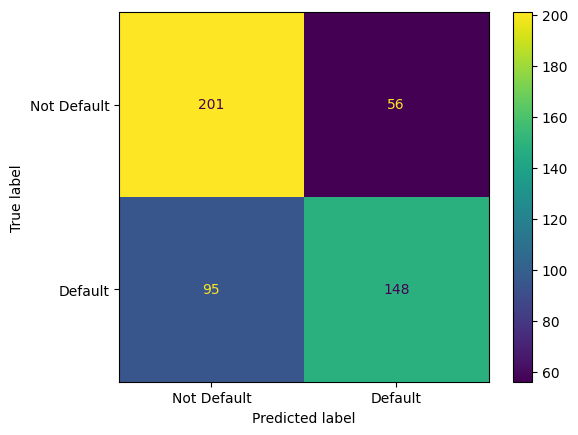

In [ ]:
y_predict = clf_svm.predict(X_test_scaled)
svm_report = classification_report(y_test , y_predict ,
                             target_names=target_names , output_dict=True)

cf_matrix = confusion_matrix(y_test , y_predict)
cf_matrix_plot = ConfusionMatrixDisplay(cf_matrix ,
                                    display_labels=target_names)
cf_matrix_plot.plot()

# **Now We Optimize the SVM**

In [ ]:
param_grid = [
    {'C': [0.5 ,1 ,10 ,100] ,
     'gamma' : ['scale',1 ,0.1 ,0.01 ,0.001 ,0.0001],
     'kernel' : ['rbf']},
]

optimal_params = GridSearchCV(
    SVC() , param_grid ,
    cv=5 , scoring="accuracy", verbose=1
)

optimal_params.fit(X_train_scaled , y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.5, 1, 10, 100],
                          'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
                          'kernel': ['rbf']}],
             scoring='accuracy', verbose=1)

In [ ]:
print(optimal_params.best_params_)

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


**Now We Build the svm again but with optimal params**

In [ ]:
clf_svm = SVC(random_state=42 , C=100 , gamma=0.001)
clf_svm.fit(X_train_scaled , y_train)

SVC(C=100, gamma=0.001, random_state=42)

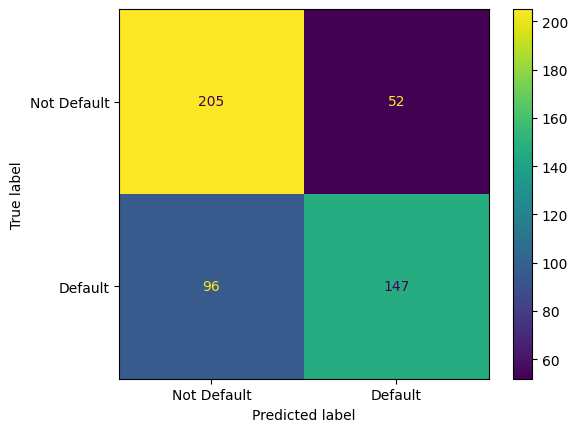

In [ ]:
y_predict_optimal= clf_svm.predict(X_test_scaled)
svm_optimal_report = classification_report(y_test , y_predict_optimal ,
                                target_names=target_names,output_dict=True)

cf_matrix_optimal = confusion_matrix(y_test , y_predict_optimal)
cf_matrix_plot_optimal = ConfusionMatrixDisplay(cf_matrix_optimal ,
                                    display_labels=target_names)
cf_matrix_plot_optimal.plot()

# **Now We try the Decision tree**

In [ ]:
clf_dt =DecisionTreeClassifier(random_state=42 , max_depth=15)
clf_dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=15, random_state=42)

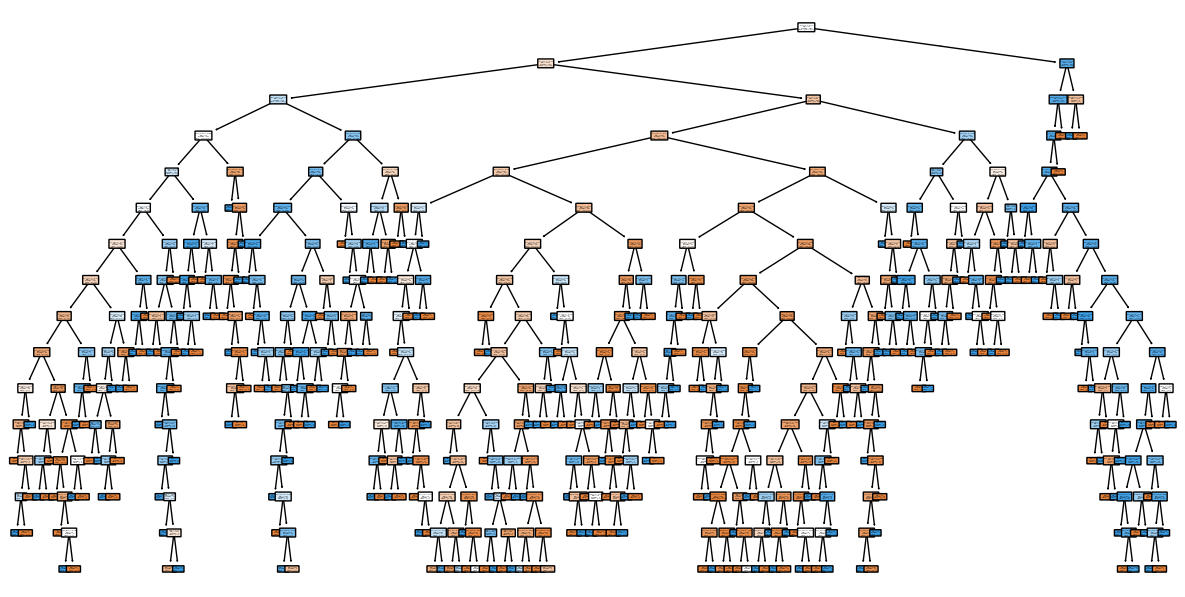

In [ ]:
plt.figure(figsize=(15 ,7.5))
plot_tree(clf_dt,
          filled= True,
          rounded= True,
          class_names=["not default","default"],
          feature_names=X_train.columns );#semi colon to show only plot

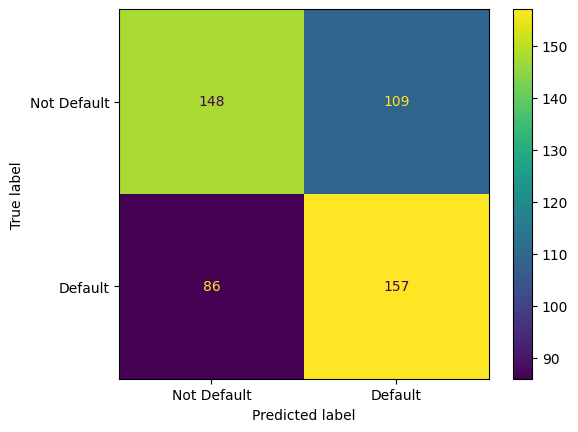

In [ ]:
y_predict = clf_dt.predict(X_test_scaled)
dt_report = classification_report(y_test , y_predict ,
                            target_names=target_names , output_dict=True)

my_cm = confusion_matrix(y_true=y_test , y_pred=y_predict)
cm_dispaly= ConfusionMatrixDisplay(confusion_matrix= my_cm ,
                                   display_labels=target_names)
cm_dispaly.plot()

In [ ]:
#cost complexity pruning (pruning param is called Alpha)
# to find Alpha is to plot accuracy of tree with differnt values of Alpha
#first we extract avaliable differnt values of alpha

#values for Alpha
path = clf_dt.cost_complexity_pruning_path(X_train_scaled , y_train)
ccp_alphas= path.ccp_alphas # extract different values of Alpha
ccp_alphas = ccp_alphas[:-1] #exclude max Alpha

clf_dts = [] # array of decision tress

# noe create one Decision Tree per Alpha value and store it in array
for ccp_alpha in ccp_alphas :
    clf_dt = DecisionTreeClassifier(random_state=42 , ccp_alpha=ccp_alpha)
    clf_dt.fit(X_train_scaled,y_train)
    clf_dts.append(clf_dt)

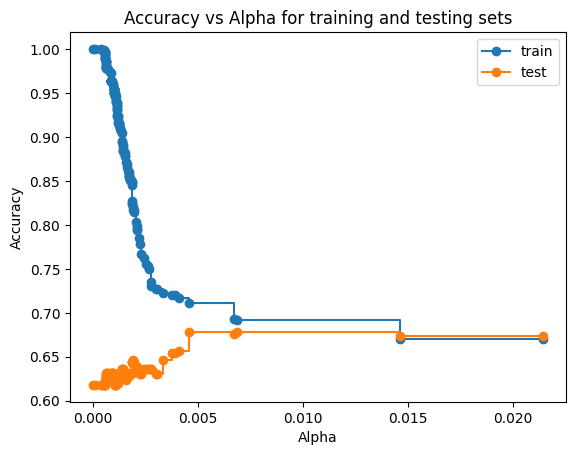

In [ ]:
#now graph tress
train_scores =[clf_dt.score(X_train_scaled , y_train) for clf_dt in clf_dts]
test_scores =[clf_dt.score(X_test_scaled , y_test) for clf_dt in clf_dts]

fig,ax = plt.subplots()
ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Alpha for training and testing sets")
ax.plot(ccp_alphas , train_scores , marker = "o" ,
        label = "train" , drawstyle = "steps-post")
ax.plot(ccp_alphas , test_scores , marker = "o" ,
        label = "test" , drawstyle = "steps-post")
ax.legend()
plt.show()


In [ ]:
print(train_scores[144:])
print(test_scores[144:])
print(ccp_alphas[144:])

#we choose ccp_alpha = 0.01462215

[0.6913333333333334, 0.67, 0.67]
[0.678, 0.674, 0.674]
[0.0068578  0.01462215 0.02147183]


<Axes: xlabel='tree'>

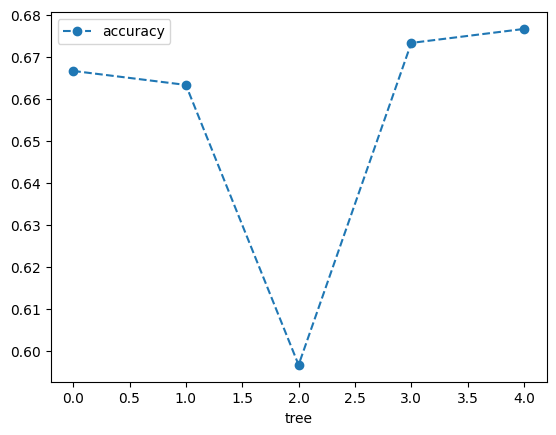

In [ ]:
best_ccp_alpha = ccp_alphas[-2]
clf_dt = DecisionTreeClassifier(random_state=42 , ccp_alpha=best_ccp_alpha)

#we use we use 5 fold because data is not way biggeer
scores = cross_val_score(clf_dt , X_train_scaled ,y_train, cv=5)
df = pd.DataFrame(data= {"tree" : range(5) , "accuracy" : scores})
df.plot(x="tree" , y="accuracy" , marker="o" , linestyle="--")

<Axes: xlabel='alpha'>

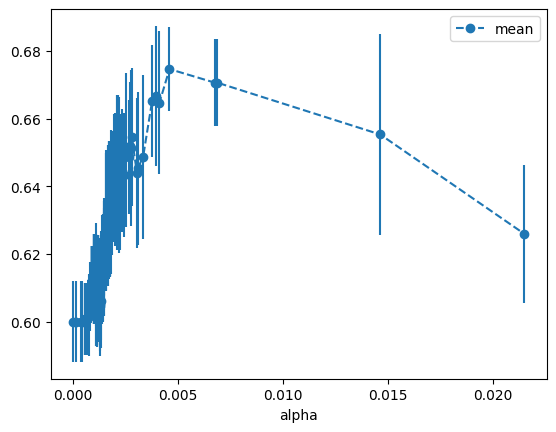

In [ ]:
#now we use cv to find optimal ccp_ALpha
alpha_loop_values = [] # stores results of each fold in CV

#for each candidate value for Alpha , we run 5 fold Cv
#then store mean and std of scores for each call

for ccp_alpha in ccp_alphas :
    clf_dt = DecisionTreeClassifier(random_state=42 , ccp_alpha=ccp_alpha)
    scores = cross_val_score (clf_dt , X_train_scaled,y_train, cv= 5)
    alpha_loop_values.append([ccp_alpha , np.mean(scores) , np.std(scores)])

#now we draw graph of means and std of scores

alpha_results = pd.DataFrame(alpha_loop_values, columns=["alpha" ,"mean","std"])

alpha_results.plot(x="alpha" , y ="mean" , yerr= "std",
                   marker="o" , linestyle="--")

In [ ]:
alpha_results[(alpha_results["alpha"] > 0.004)
               &
               (alpha_results["alpha"] < 0.010)]

,alpha,mean,std
141,0.004106,0.664667,0.021145
142,0.004588,0.674667,0.012401
143,0.006737,0.670667,0.012893
144,0.006858,0.670667,0.012893


In [ ]:
ideal_ccp_alpha = 0.004588

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


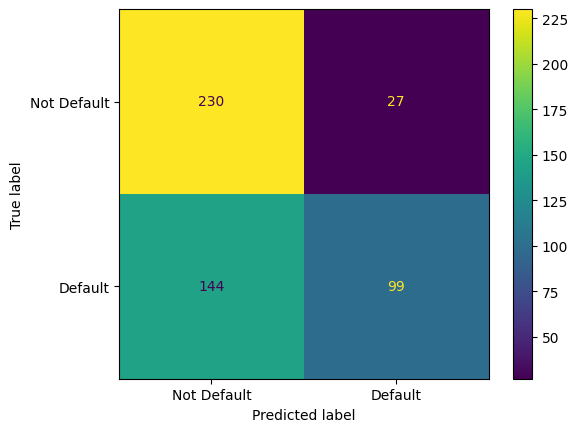

In [ ]:
#now we have ideal alpha
#now we bulid ,evaluate ,draw and interpreting final classification tree

clf_dt_pruned = DecisionTreeClassifier(random_state=42 ,
                                       ccp_alpha=ideal_ccp_alpha)

clf_dt_pruned=clf_dt_pruned.fit(X_train_scaled,y_train)
y_predict=clf_dt_pruned.predict(X_test)
dt_pruned_report = classification_report(y_test , y_predict ,
                             target_names=target_names , output_dict=True)

my_cm = confusion_matrix(y_true=y_test , y_pred=y_predict)
pruned_disp =ConfusionMatrixDisplay(my_cm ,
                                    display_labels=target_names)

pruned_disp.plot()

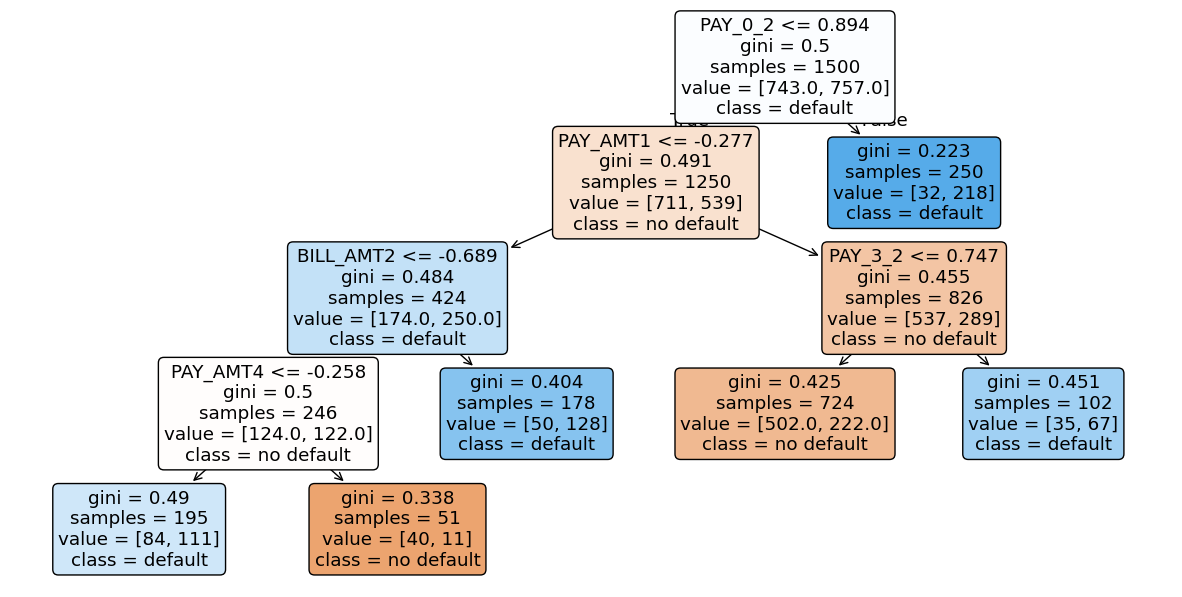

In [ ]:
#now we plot tree
plt.figure(figsize=(15 ,7.5))
plot_tree(clf_dt_pruned,
          filled= True,
          rounded= True,
          class_names=["no default","default"],
          feature_names=X_train.columns );#semi colon to show only plot

# **Random Forest**

In [ ]:
clf_RF = RandomForestClassifier(random_state=42 )
clf_RF.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_RF = clf_RF.predict(X_test_scaled)
RF_report = classification_report(y_test , y_pred_RF ,
                            target_names=target_names,output_dict=True)

In [ ]:
print("svm_report::\n")
print(svm_report)
print(50*"#")
print("svm_optimal_report:\n")
print(svm_optimal_report)
print(50*"#")
print("Decision_Tree_report:\n")
print(dt_report)
print(50*"#")
print("Decision_Tree_pruned_report:\n")
print(dt_pruned_report)
print(50*"#")
print("Random_Forest_report:\n")
print(RF_report)

svm_report::

              precision    recall  f1-score   support

 Not Default       0.68      0.78      0.73       257
     Default       0.73      0.61      0.66       243

    accuracy                           0.70       500
   macro avg       0.70      0.70      0.69       500
weighted avg       0.70      0.70      0.70       500

##################################################
svm_optimal_report:

              precision    recall  f1-score   support

 Not Default       0.68      0.80      0.73       257
     Default       0.74      0.60      0.67       243

    accuracy                           0.70       500
   macro avg       0.71      0.70      0.70       500
weighted avg       0.71      0.70      0.70       500

##################################################
Decision_Tree_report:

              precision    recall  f1-score   support

 Not Default       0.63      0.58      0.60       257
     Default       0.59      0.65      0.62       243

    accuracy          